In [14]:
# 1. Import Dependencies
import pandas as pd
import numpy as np
import random
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, train_test_split
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
df = pd.read_csv("extracted_columns.csv")

# Prepare features and target
X = df[['PSS-1', 'PSS-2', 'PSS-3', 'PSS-4', 'PSS-5', 'PSS-6', 'PSS-7',
        'PSS-8', 'PSS-9', 'PSS-10', 'PSS-11', 'PSS-12', 'PSS-13', 'PSS-14']]
df['PSS_total'] = X.sum(axis=1)
y = df['PSS_total']

In [3]:
# Split data into training and validation sets (80/20 split)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# Evaluation and plotting function
def evaluate_and_plot(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name} RMSE: {rmse:.4f}")
    print(f"{model_name} MAE: {mae:.4f}")
    print(f"{model_name} R^2: {r2:.4f}")

    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.show()

In [5]:
# SVR fitness function using k-fold CV on training data
def fitness_kfold_svr(individual, X_train, y_train, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmse_scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = make_pipeline(
            StandardScaler(),
            SVR(C=individual['C'], epsilon=individual['epsilon'], kernel=individual['kernel'])
        )
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val_fold)
        rmse_scores.append(np.sqrt(mean_squared_error(y_val_fold, preds)))
    return -np.mean(rmse_scores)


In [15]:
# Genetic Algorithm implementation for SVR hyperparameter tuning
def genetic_algorithm_kfold_svr(X_train, y_train, generations=10, population_size=20, k=5):
    param_bounds = {
        'C': [0.1, 1000],
        'epsilon': [0.01, 1.0],
        'kernel': ['linear', 'rbf']
    }
    def create_individual():
        return {
            'C': random.uniform(param_bounds['C'][0], param_bounds['C'][1]),
            'epsilon': random.uniform(param_bounds['epsilon'][0], param_bounds['epsilon'][1]),
            'kernel': random.choice(param_bounds['kernel'])
        }
    def mutate(individual, mutation_rate=0.1):
        if random.random() < mutation_rate:
            individual['C'] += random.uniform(-10, 10)
            individual['C'] = np.clip(individual['C'], param_bounds['C'][0], param_bounds['C'][1])
        if random.random() < mutation_rate:
            individual['epsilon'] += random.uniform(-0.05, 0.05)
            individual['epsilon'] = np.clip(individual['epsilon'], param_bounds['epsilon'][0], param_bounds['epsilon'][1])
        if random.random() < mutation_rate:
            individual['kernel'] = random.choice(param_bounds['kernel'])
        return individual
    def crossover(parent1, parent2):
        child = {}
        for key in parent1.keys():
            child[key] = parent1[key] if random.random() > 0.5 else parent2[key]
        return child
    population = [create_individual() for _ in range(population_size)]
    for individual in population:
        individual['fitness'] = fitness_kfold_svr(individual, X_train, y_train, k=k)
    for gen in range(generations):
        new_population = []
        while len(new_population) < population_size:
            parent1 = max(random.sample(population, 3), key=lambda ind: ind['fitness'])
            parent2 = max(random.sample(population, 3), key=lambda ind: ind['fitness'])
            child = crossover(parent1, parent2)
            child = mutate(child)
            child['fitness'] = fitness_kfold_svr(child, X_train, y_train, k=k)
            new_population.append(child)
        population = new_population
        best = max(population, key=lambda ind: ind['fitness'])
        print(f"Generation {gen+1}, Best RMSE: {-best['fitness']:.4f}, Params: {best}")
    best_individual = max(population, key=lambda ind: ind['fitness'])
    return best_individual


In [16]:
# Run multiple GA optimizations on training data to finalize the hyperparameters
def multiple_ga_runs(X_train, y_train, runs=30):
    results = []
    for run in range(runs):
        print(f"\n=== GA Run {run+1}/{runs} ===")
        seed = 42 + run
        random.seed(seed)
        np.random.seed(seed)
        best_params = genetic_algorithm_kfold_svr(X_train, y_train)
        model = make_pipeline(
            StandardScaler(),
            SVR(C=best_params['C'], epsilon=best_params['epsilon'], kernel=best_params['kernel'])
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_train)
        rmse = np.sqrt(mean_squared_error(y_train, preds))
        mae = mean_absolute_error(y_train, preds)
        r2 = r2_score(y_train, preds)
        results.append({
            'Run': run+1,
            'Seed': seed,
            'C': best_params['C'],
            'epsilon': best_params['epsilon'],
            'kernel': best_params['kernel'],
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        })
        print(f"Run {run+1} Metrics -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")
    rmse_vals = [r['RMSE'] for r in results]
    mae_vals = [r['MAE'] for r in results]
    r2_vals = [r['R2'] for r in results]
    print("\n=== Final 30-Run Summary ===")
    print(f"Average RMSE: {np.mean(rmse_vals):.4f} ± {np.std(rmse_vals):.4f}")
    print(f"Average MAE: {np.mean(mae_vals):.4f} ± {np.std(mae_vals):.4f}")
    print(f"Average R^2: {np.mean(r2_vals):.4f} ± {np.std(r2_vals):.4f}")
    results_df = pd.DataFrame(results)
    results_df.to_csv("GA_SVR_30_Run_Results.csv", index=False)
    plt.figure(figsize=(12,6))
    plt.subplot(1, 3, 1)
    plt.boxplot(rmse_vals)
    plt.title("RMSE Distribution")
    plt.ylabel("RMSE")
    plt.subplot(1, 3, 2)
    plt.boxplot(mae_vals)
    plt.title("MAE Distribution")
    plt.ylabel("MAE")
    plt.subplot(1, 3, 3)
    plt.boxplot(r2_vals)
    plt.title("R^2 Distribution")
    plt.ylabel("R^2")
    plt.suptitle("GA-Optimized SVR Performance over Multiple Runs")
    plt.tight_layout()
    plt.show()
    return results_df



=== GA Run 1/30 ===
Generation 1, Best RMSE: 0.0148, Params: {'C': 609.1700925664215, 'epsilon': 0.034760647670440264, 'kernel': 'linear', 'fitness': np.float64(-0.014752780613098001)}
Generation 2, Best RMSE: 0.0148, Params: {'C': 609.1700925664215, 'epsilon': 0.034760647670440264, 'kernel': 'linear', 'fitness': np.float64(-0.014752780613098001)}
Generation 3, Best RMSE: 0.0148, Params: {'C': np.float64(214.98820720151758), 'epsilon': 0.034760647670440264, 'kernel': 'linear', 'fitness': np.float64(-0.014752780613098001)}
Generation 4, Best RMSE: 0.0148, Params: {'C': np.float64(609.4791327647258), 'epsilon': 0.034760647670440264, 'kernel': 'linear', 'fitness': np.float64(-0.014752780613098001)}
Generation 5, Best RMSE: 0.0073, Params: {'C': 609.1700925664215, 'epsilon': np.float64(0.01723746561499165), 'kernel': 'linear', 'fitness': np.float64(-0.007338953224046371)}
Generation 6, Best RMSE: 0.0073, Params: {'C': 609.1700925664215, 'epsilon': np.float64(0.01723746561499165), 'kernel'

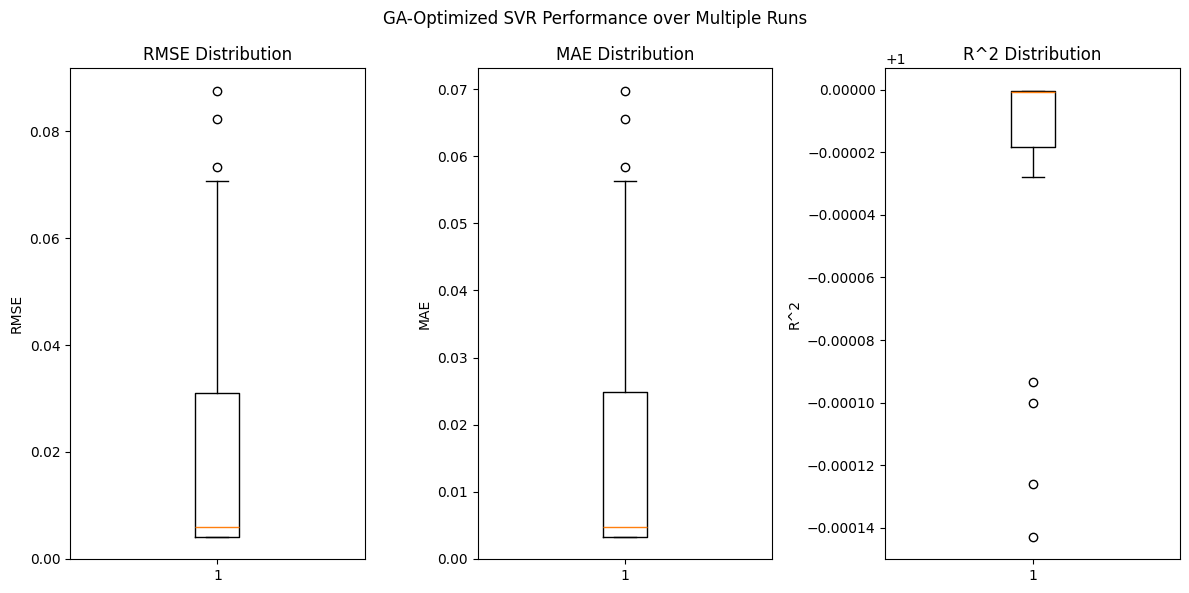

In [17]:
# Run GA hyperparameter tuning on training data
results_df = multiple_ga_runs(X_train, y_train, runs=30)


In [18]:
# Select best parameters from GA run with lowest RMSE
best_run = results_df.iloc[results_df['RMSE'].idxmin()]
best_params = {
    'C': best_run['C'],
    'epsilon': best_run['epsilon'],
    'kernel': best_run['kernel']
}
print(f"Best hyperparameters: {best_params}")

Best hyperparameters: {'C': np.float64(852.3289980931934), 'epsilon': np.float64(0.01), 'kernel': 'linear'}


In [19]:
# Train final model on full training set with best parameters
final_svr_model = make_pipeline(
    StandardScaler(),
    SVR(C=best_params['C'], epsilon=best_params['epsilon'], kernel=best_params['kernel'])
)
final_svr_model.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0


Final GA-Optimized SVR on Validation Set RMSE: 0.0044
Final GA-Optimized SVR on Validation Set MAE: 0.0035
Final GA-Optimized SVR on Validation Set R^2: 1.0000


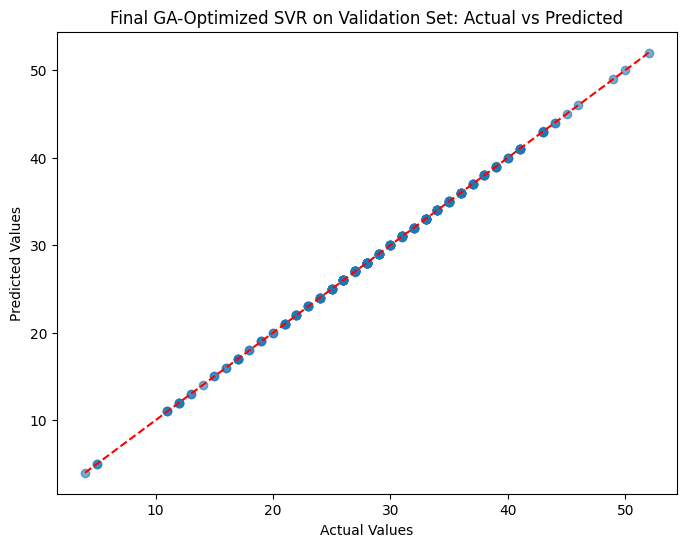

In [21]:
# Evaluate final model on held-out validation set
y_val_pred = final_svr_model.predict(X_val)
evaluate_and_plot('Final GA-Optimized SVR on Validation Set', y_val, y_val_pred)